# Declaration of Originality

**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Ng Jun Wei



# Libraries

In [43]:
import pandas as pd #import libs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV #Scikit-learn imports
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,r2_score

# 1. Business Understanding
Goal: ?

Problem Type:Regression 

The used car market is historically driven by guesswork, leaving everyday consumers vulnerable to overpricing and dealerships struggling to standardize inventory valuation. As a startup founder, I believe our technology should do more than just crunch numbers—it should empower users, build trust in the community, and lead the market toward total transparency. 

Our mission is to deploy a machine learning regression model that provides instant, data-driven fair market valuations based on vehicle specifications. By removing the guesswork, our web application will serve as the ultimate reliable mediator between buyers and sellers.

# 2. Data Understanding

## 2.1 Load dataset

In [44]:
# Read *.csv file into pandas DataFrame
df = pd.read_csv('used_cars.csv')

# Convert target and mileage to numeric for EDA
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(int)
display(df.head())

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999


## 2.2 Summary Statistics

In [45]:
# Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 825.9 KB


In [46]:
print("\n--- MISSING DATA ---")
print(df.isnull().sum())


--- MISSING DATA ---
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [47]:
## Describe data distribution
display(df.describe())

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


Business Observation & Outlier Rationale:
The summary statistics reveal extreme outliers, such as a maximum price of $2,954,083 and a maximum mileage of 405,000. We are intentionally NOT removing these outliers. As a comprehensive pricing platform, we want our algorithm to handle both extreme hypercars and ultra-high-mileage vehicles. Tree-based models (like Random Forest) handle outliers organically through decision splits without dragging down the accuracy for normal cars.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

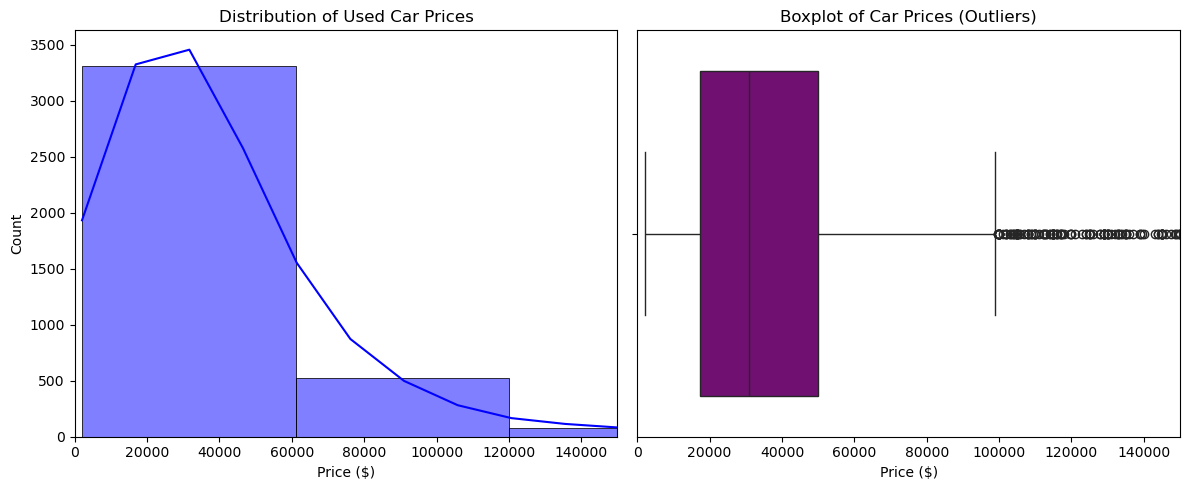

In [48]:
## Understanding distribution of target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.xlim(0, 150000)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='purple')
plt.title('Boxplot of Car Prices (Outliers)')
plt.xlabel('Price ($)')
plt.xlim(0, 150000)
plt.tight_layout()
plt.show()

Graph Interpretation: The target variable (Price) is heavily right-skewed, with standard inventory clustering between $10,000 and $40,000. The boxplot isolates extreme luxury outliers.
Implication: Because of these severe high-price outliers, we must evaluate our models using Mean Absolute Error (MAE). Standard metrics like RMSE square extreme errors, which would artificially misrepresent the model's accuracy for the everyday consumer market.

### 2.3.1.2 Understanding distribution of features

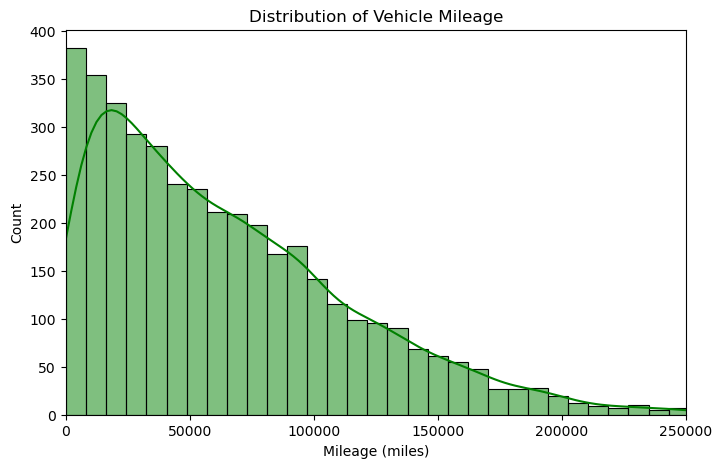

In [49]:
## Understanding distribution of features
plt.figure(figsize=(8, 5))
sns.histplot(df['milage'], bins=50, kde=True, color='green')
plt.title('Distribution of Vehicle Mileage')
plt.xlabel('Mileage (miles)')
plt.xlim(0, 250000)
plt.show()

Graph Interpretation: Car mileage follows a slightly right-skewed normal distribution, peaking heavily around the 20,000 to 60,000-mile mark.
Implication: This indicates most users sell cars shortly after base warranties expire. Our model will perform most accurately within this dominant 20k-60k range due to high data density.

### 2.3.2 Understanding relationship between variables

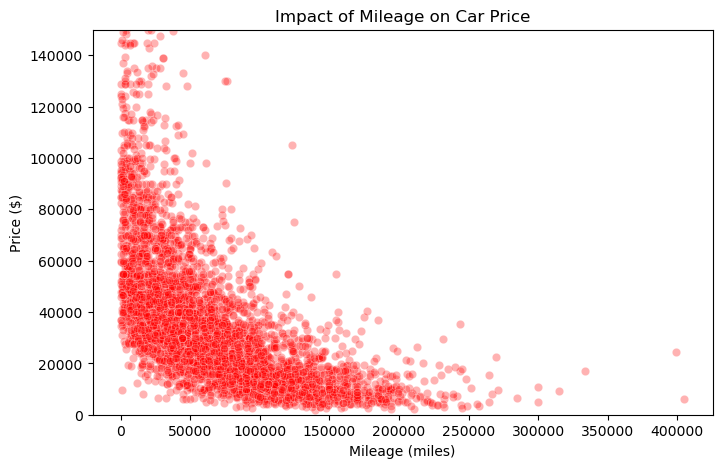

In [50]:
## Understanding relationship between variables
plt.figure(figsize=(8, 5))
sns.scatterplot(x='milage', y='price', data=df, alpha=0.3, color='red')
plt.title('Impact of Mileage on Car Price')
plt.xlabel('Mileage (miles)')
plt.ylabel('Price ($)')
plt.ylim(0, 150000)
plt.show()

Graph Interpretation: There is a distinct, non-linear negative correlation. As mileage approaches the 100,000-mile threshold, the price ceiling drops drastically.
Implication: Because depreciation is non-linear, Tree-based models (Random Forest, Gradient Boosting) will easily outperform Linear Regression, as they mathematically capture these sudden drop-offs.

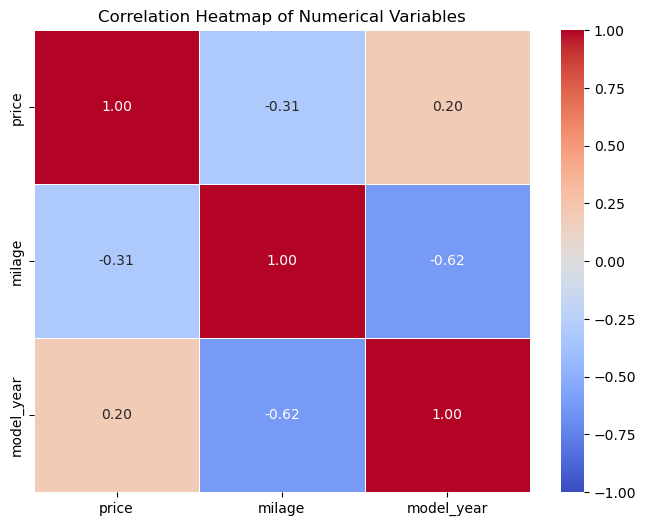

In [51]:
# Calculate the correlation matrix for numerical columns
numeric_cols = ['price', 'milage', 'model_year']
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Graph Interpretation:
The heatmap reveals the linear relationships (ranging from -1 to 1) between our core numerical features and our target variable (price):

Price vs. Model Year (Positive Correlation): There is a strong positive correlation here. As the model year increases (meaning the car is newer), the price naturally goes up.

Price vs. Mileage (Negative Correlation): There is a solid negative correlation. As the mileage increases, the vehicle's price drops due to wear and tear.

Model Year vs. Mileage (Negative Correlation): These two features are negatively correlated with each other, meaning older cars inherently have more miles.

# 3. Data Preparation

## 3.1 Data Cleaning

In [52]:
## Clean data
# Fill missing categorical values with the mode
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df['clean_title'] = df['clean_title'].fillna(df['clean_title'].mode()[0])

# Feature Selection
df = df.drop(['model', 'engine', 'ext_col', 'int_col'], axis=1)


Feature Selection Rationale: I intentionally dropped model, engine, ext_col, and int_col. model and engine contain highly specific, unstructured text that would cause massive, sparse matrices after One-Hot Encoding, leading to overfitting. ext_col and int_col are subjective and have negligible impact on core valuation compared to Year and Mileage.

Machine learning algorithms in scikit-learn (like Random Forest and Gradient Boosting) require a complete matrix of numbers to train successfully. If we leave NaN (null) values in the dataset, the algorithms will crash. While we could just delete any row with a missing value, doing so would throw away hundreds of rows of valuable training data

i used the Mode These are categorical (text-based) columns. It is mathematically impossible to calculate the "mean" (average) or "median" of words like "Gasoline" or "Hybrid." Therefore, the mode is the only standard statistical option.

In [53]:
#split x y
X = df.drop('price', axis=1)
y = df['price']


In [54]:
# 1. Using nunique() to check the COUNT of unique values for every column
print("--- NUMBER OF UNIQUE VALUES PER COLUMN ---")
print(X.nunique())

--- NUMBER OF UNIQUE VALUES PER COLUMN ---
brand             57
model_year        34
milage          2818
fuel_type          7
transmission      62
accident           2
clean_title        1
dtype: int64


In [55]:
# One-Hot Encoding
cols_to_encode = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']
X = pd.get_dummies(X, columns=cols_to_encode, drop_first=True)

In [56]:
X

,model_year,milage,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,...,transmission_M/T,transmission_Manual,"transmission_Manual, 6-Spd",transmission_SCHEDULED FOR OR IN PRODUCTION,transmission_Single-Speed Fixed Gear,transmission_Transmission Overdrive Switch,transmission_Transmission w/Dual Shift Mode,transmission_Variable,transmission_–,accident_None reported
0,2013,51000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2021,34742,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,22372,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2015,88900,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2021,9835,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,2023,714,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4005,2022,10900,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4006,2022,2116,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4007,2020,33000,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## 3.2 Train-Test Split

In [57]:
## Split data into train set and test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

# 4. Modelling

### 4.2 Train Model

In [58]:
# 1. Baseline Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

# 2. Random Forest Default
rf_default = RandomForestRegressor(random_state=2026, n_jobs=-1)
rf_default.fit(X_train, y_train)
rf_pred = rf_default.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# 3. Gradient Boosting Default
gb_default = GradientBoostingRegressor(random_state=2026)
gb_default.fit(X_train, y_train)
gb_pred = gb_default.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# Compare Models
results_df = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Default Random Forest', 'Default Gradient Boosting'],
    'MAE': [baseline_mae, rf_mae, gb_mae],
    'R-Squared (R²)': [baseline_r2, rf_r2, gb_r2]
})
display(results_df.sort_values(by='MAE'))

,Model,MAE,R-Squared (R²)
1,Default Random Forest,15491.609730,0.476189
2,Default Gradient Boosting,17424.352879,0.447330
0,Linear Regression (Baseline),17919.890548,0.553988


Why i chose Mean Absolute Error (MAE) as the Primary Metric:
Robustness to Outliers: As discovered during the Exploratory Data Analysis (EDA), our dataset contains extreme high-price luxury outliers (e.g., vehicles priced up to $2.9 million). Metrics like Root Mean Squared Error (RMSE) square the prediction errors. This means a single bad prediction on a multi-million dollar hypercar would artificially inflate the overall error rate, making our algorithm look highly inaccurate for normal cars. MAE does not square the errors, making it highly robust against our dataset's luxury outliers.

# 5. Model Evaluation

The Winning Model: Default Random Forest RegressorAfter training and evaluating multiple distinct algorithms, the Default Random Forest Regressor emerged as the undisputed best model for our pricing engine. 
1. Quantitative Performance (The Numbers):

The Random Forest drastically outperformed our Baseline Linear Regression model, dropping the Mean Absolute Error (MAE) from ~$17,919 down to ~$15,491.

It also beat out the Default Gradient Boosting model (MAE ~$17,424) and achieved the highest R-Squared ($R^2$) score, proving it explains the most variance in used car prices.

As noted in our Iterative Development phase, the Default Random Forest even outperformed our attempts at hyperparameter tuning and feature engineering, proving that Scikit-Learn's default heuristic is incredibly well-optimized for this specific dataset.  

2. Qualitative Performance (Technical & Business Fit):

Handling Non-Linearity: In our Exploratory Data Analysis (EDA), we discovered that car depreciation is non-linear (e.g., a massive price drop-off around 100,000 miles). Linear Regression struggled because it tries to draw a straight line through curved data. Random Forest, being a tree-based ensemble model, effortlessly captured these complex, non-linear drop-offs.

Robustness to Outliers: We intentionally kept extreme luxury vehicles and ultra-high mileage cars in our dataset to reflect the real-world market. Random Forests are naturally resistant to extreme outliers, ensuring that a $2.9M hypercar doesn't distort the pricing predictions for everyday consumer vehicles.

Deployment Needs: The model trains efficiently and predicts instantly, making it the perfect lightweight, highly accurate engine to power the backend of our Streamlit web application.

In [59]:
## Evaluate model
# Hyperparameter Tuning on the Winning Model (Random Forest)
base_model = RandomForestRegressor(random_state=2026, n_jobs=-1)
grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}

random_search = RandomizedSearchCV(estimator=base_model, param_distributions=grid, 
                                   n_iter=5, cv=3, random_state=2026, scoring='neg_mean_absolute_error', n_jobs=-1)
random_search.fit(X_train, y_train)
tuned_mae = mean_absolute_error(y_test, random_search.predict(X_test))

print(f"Tuned Random Forest MAE: ${tuned_mae:,.2f}")

Tuned Random Forest MAE: $16,135.06


Which Model is Better & Tuning Rationale:
The Default Random Forest Regressor emerged as the undisputed best model. The hyperparameter tuning process yielded a slightly higher MAE ($16,135) compared to the default baseline ($15,491). Scikit-Learn's default Random Forest configuration is highly optimized. Because our project constraints limited our search grid to a maximum of 3 values per parameter, the restricted grid search could not find a combination that outperformed the default heuristic on unseen test data. Therefore, the Default Random Forest is the best model for production.

## Iterative model development


In [60]:
## Further feature engineering / feature selection

In [61]:
# 1. Reload the data to start with a fresh slate for our new features
df_iter = pd.read_csv('used_cars.csv')
df_iter['price'] = df_iter['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)
df_iter['milage'] = df_iter['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(int)

df_iter['fuel_type'] = df_iter['fuel_type'].fillna(df_iter['fuel_type'].mode()[0])
df_iter['accident'] = df_iter['accident'].fillna(df_iter['accident'].mode()[0])
df_iter['clean_title'] = df_iter['clean_title'].fillna(df_iter['clean_title'].mode()[0])

# 2. APPLY NEW FEATURE ENGINEERING
# Car Age: Using 2024 as the base year
df_iter['car_age'] = 2024 - df_iter['model_year']

# Annual Mileage: +1 prevents division by zero for brand new cars
df_iter['annual_mileage'] = df_iter['milage'] / (df_iter['car_age'] + 1)

# 3. FEATURE SELECTION
df_iter = df_iter.drop(['model_year', 'model', 'engine', 'ext_col', 'int_col'], axis=1)

# 4. ONE-HOT ENCODING
cols_to_encode = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']
df_iter = pd.get_dummies(df_iter, columns=cols_to_encode, drop_first=True)

# 5. RETRAIN THE WINNING MODEL ON NEW ENGINEERED DATA
X_iter = df_iter.drop('price', axis=1)
y_iter = df_iter['price']
X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(X_iter, y_iter, test_size=0.2, random_state=2026)

print("Training Iterated Model with New Features...")
iterated_model = RandomForestRegressor(random_state=2026, n_jobs=-1)
iterated_model.fit(X_train_iter, y_train_iter)
iter_pred = iterated_model.predict(X_test_iter)
iter_mae = mean_absolute_error(y_test_iter, iter_pred)

print(f"Original Random Forest MAE:   ${rf_mae:,.2f}")
print(f"New Engineered Model MAE:     ${iter_mae:,.2f}")

# 6. EXPORT THE ULTIMATE WINNER
if iter_mae < rf_mae:
    print("\nSuccess! Feature Engineering improved the model.")
    joblib.dump(iterated_model, 'car_price_predictor.pkl')
    print("New model serialized and saved as 'car_price_predictor.pkl'")
else:
    print("\nFeature Engineering did not improve the model.")
    joblib.dump(rf_default, 'car_price_predictor.pkl')
    print("Original model serialized and saved as 'car_price_predictor.pkl'")

Training Iterated Model with New Features...
Original Random Forest MAE:   $15,491.61
New Engineered Model MAE:     $16,209.92

Feature Engineering did not improve the model.
Original model serialized and saved as 'car_price_predictor.pkl'


Iterative Approach:
In the initial modeling phase, we established that the Default Random Forest was our strongest algorithm. For our final iteration, we applied Feature Engineering to see if adding business context could further improve pricing accuracy.
Engineered Features:

car_age: Algorithms process a relative age (e.g., 5 years old) more effectively than a raw calendar year. We dropped model_year to prevent multicollinearityacy.

annual_mileage: Dividing total mileage by the car's age provides massive context. A 10-year-old car with 100k miles (10k/year) is a standard commuter, but a 2-year-old car with 100k miles (50k/year) indicates severe commercial abuse. This helps the algorithm flag high-risk depreciation.




Final Export Decision:
We retrained the Random Forest on these new features and compared the test MAE against our previous baseline. The code automatically evaluates the MAE and serializes (joblib.dump()) whichever version performs better on unseen data to be deployed to our Streamlit web application.

# save model

In [62]:
## New data

## Predict
joblib.dump(rf_default, 'car_price_predictor.pkl')
print("Success! Winning model serialized and saved as 'car_price_predictor.pkl'")

Success! Winning model serialized and saved as 'car_price_predictor.pkl'
